# Chapter 3: Linear Regression for a housing dataset

### Importing the necessary packages

In [1]:
!git clone https://github.com/s7s/machine_learning_1
%cd  machine_learning_1/linear_regression
# https://docs.google.com/presentation/d/1NfC05Wi6sAkbS9U4X6RW9jyW5auU901wPTRAtopw9qA/edit?usp=drive_link

Cloning into 'machine_learning_1'...
remote: Enumerating objects: 378, done.
remote: Counting objects: 100% (126/126), done.
remote: Compressing objects: 100% (125/125), done.
remote: Total 378 (delta 74), reused 3 (delta 1), pack-reused 252 (from 1)
Receiving objects: 100% (378/378), 42.71 MiB | 12.74 MiB/s, done.
Resolving deltas: 100% (197/197), done.
/content/machine_learning_1/linear_regression


In [2]:
from matplotlib import pyplot as plt
import numpy as np
import random
import utils

### Defining and plotting our dataset

In [3]:
features = np.array([1,2,3,5,6,7])
labels = np.array([155, 197, 244, 356,407,448])

print(features)
print(labels)

[1 2 3 5 6 7]
[155 197 244 356 407 448]


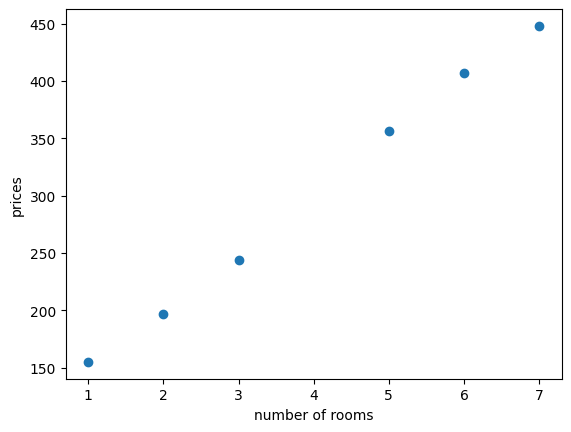

In [4]:
utils.plot_points(features, labels)

### Coding the tricks

- Simple trick
- Absolute trick
- Square trick

In [ ]:
def simple_trick(base_price, price_per_room, num_rooms, price):
    small_random_1 = random.random()*0.1
    small_random_2 = random.random()*0.1
    predicted_price = base_price + price_per_room*num_rooms
    if price > predicted_price and num_rooms > 0:
        price_per_room += small_random_1
        base_price += small_random_2
    if price > predicted_price and num_rooms < 0:
        price_per_room -= small_random_1
        base_price += small_random_2
    if price < predicted_price and num_rooms > 0:
        price_per_room -= small_random_1
        base_price -= small_random_2
    if price < predicted_price and num_rooms < 0:
        price_per_room += small_random_1
        base_price -= small_random_2
    return price_per_room, base_price

In [5]:
def square_trick(base_price, price_per_room, num_rooms, price, learning_rate):
    ## TODO ##
    #implement square_trick and return the new price_per_room and base_price
    # calculate the predicted price then calculate the new price_per_room and base_price
    predicted_price = base_price + price_per_room * num_rooms

    # implement absolute_trick and return the new price_per_room and base_price
    if price > predicted_price:
        price_per_room += learning_rate
        base_price += learning_rate
    elif price < predicted_price:
        price_per_room -= learning_rate
        base_price -= learning_rate
    return price_per_room, base_price

In [ ]:
def absolute_trick(base_price, price_per_room, num_rooms, price, learning_rate):
    ## TODO ##
    #implement absolute_trick and return the new price_per_room and base_price
    # calculate the predicted price then calculate the new price_per_room and base_price

    return price_per_room, base_price

### Running the linear regression algorithm

The linear regression algorithm consists of:
- Starting with random weights
- Iterating the square (or simple, or absolute) trick many times.

Price per room: 0.8444218515250481
Base price: 0.7579544029403025


(0.8444218515250481, 0.7579544029403025)

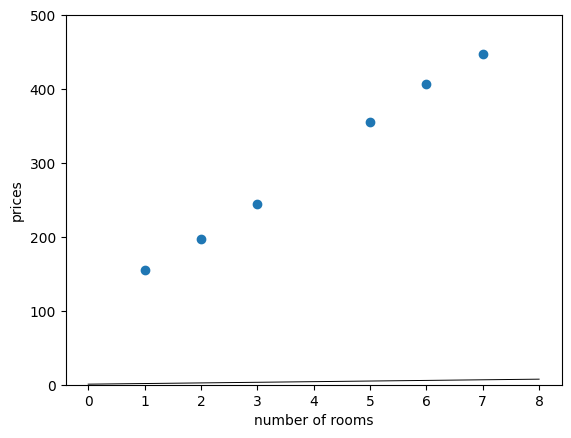

In [7]:
import random as rd

# We set the random seed in order to always get the same results.
random.seed(0)

def linear_regression(features, labels, learning_rate=0.01, epochs = 1000):
    price_per_room =  random.random() # start with random weight
    base_price =  random.random() # start with random bias
    ## TODO ##
    # for this number of epochs
    # get a random datasample of our dataset(x,y)
    # using the selected datasample use square_trick fn or absolute_trick fn to update price_per_room and base_price

    utils.draw_line(price_per_room, base_price, 'black', starting=0, ending=8)
    utils.plot_points(features, labels)
    print('Price per room:', price_per_room)
    print('Base price:', base_price)
    return price_per_room, base_price

# This line is for the x-axis to appear in the figure
plt.ylim(0,500)

linear_regression(features, labels, learning_rate = 0.01, epochs = 1000)

### Root mean squared error function

In [9]:
# The root mean square error function
def rmse(labels, predictions):
    ## TODO ##
    # calculate the root meen square error between the labels and predictions
    error = 0
    for i in range(len(labels)):
        error += (labels[i] - predictions[i])**2
    return error

### Plotting the error function

Price per room: 59.858988002437854
Base price: 59.556120416243886


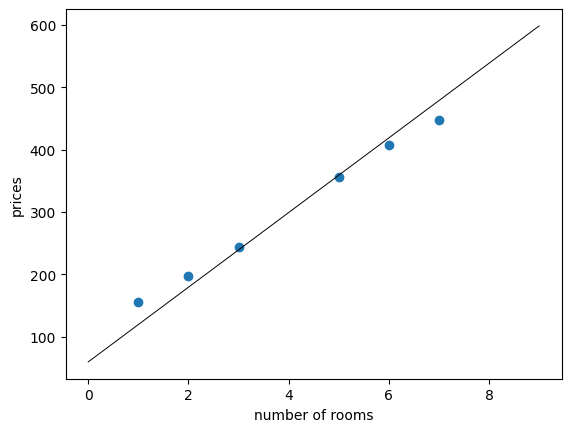

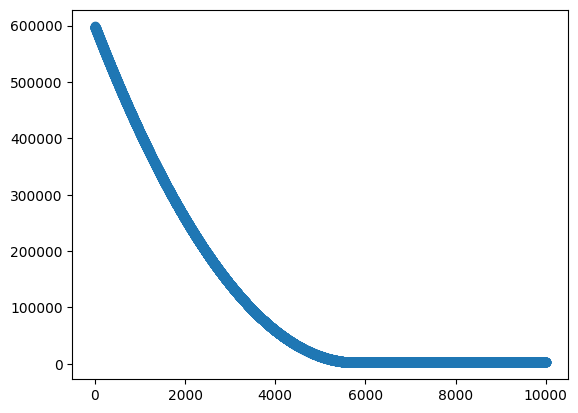

(59.858988002437854, 59.556120416243886)

In [12]:
def linear_regression(features, labels, learning_rate=0.01, epochs = 1000):
    price_per_room = random.random()
    base_price = random.random()
    errors = []
    for i in range(epochs):
        predictions = features*price_per_room+base_price
        errors.append(rmse(labels, predictions))
        i = random.randint(0, len(features)-1)
        num_rooms = features[i]
        price = labels[i]
        # Uncomment one of the following 3 lines to use the simple, the absolute, or the square trick
        #price_per_room, base_price = simple_trick(base_price,
        #price_per_room, base_price = absolute_trick(base_price,
        price_per_room, base_price = square_trick(base_price,
                                                  price_per_room,
                                                  num_rooms,
                                                  price,
                                                  learning_rate=learning_rate)
    utils.draw_line(price_per_room, base_price, 'black', starting=0, ending=9)
    utils.plot_points(features, labels)
    print('Price per room:', price_per_room)
    print('Base price:', base_price)
    plt.show()
    plt.scatter(range(epochs), errors)
    plt.show()
    return price_per_room, base_price

linear_regression(features, labels, learning_rate = 0.01, epochs = 10000)

### Linear regression using sklearn



In [ ]:
from sklearn.linear_model import SGDRegressor

# Reshape features to a 2D array as required by SGDRegressor
features_reshaped = features.reshape(-1, 1)

# Use sklearn to implement linear regression (SGDRegressor) that fit our data (features, labels)
sgd_regressor = SGDRegressor(tol=None, max_iter=1000)
sgd_regressor.fit(features_reshaped, labels)

In [ ]:
## TODO ##
# print the coefficients and bias of this model


In [ ]:
## TODO ##
# use this model to predict the price of house that contains 4 rooms


### Normal Equation



In [ ]:
def Normal_Equation(features,labels):
    ## TODO ##
    # Use normal equation to get the weights
    # don't forget to concatenate ones to the features

    return W

W = Normal_Equation(features,labels)
print(W)

### Real Example (Predict fuel efficiency)

In [ ]:
# Use seaborn for pairplot.
!pip install -q seaborn

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Make NumPy printouts easier to read.
np.set_printoptions(precision=3, suppress=True)

#### Get data

In [ ]:
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
                'Acceleration', 'Model Year', 'Origin']

raw_dataset = pd.read_csv(url, names=column_names,
                          na_values='?', comment='\t',
                          sep=' ', skipinitialspace=True)

In [ ]:
dataset = raw_dataset.copy()
dataset.head()

#### Clean data

In [ ]:
dataset.isna().sum()

In [ ]:
dataset = dataset.dropna()

In [ ]:
dataset.isna().sum()

In [ ]:
dataset.head()

In [ ]:
dataset['Origin'] = dataset['Origin'].map({1: 'USA', 2: 'Europe', 3: 'Japan'})

In [ ]:
dataset = pd.get_dummies(dataset, columns=['Origin'], prefix='', prefix_sep='')

In [ ]:
dataset.head()

In [ ]:
sns.pairplot(dataset[['MPG','Displacement', 'Horsepower', 'Weight','Acceleration']])

In [ ]:
datasetXsingle=dataset[['Horsepower']]
datasetXMulti=dataset[['Cylinders', 'Displacement', 'Horsepower', 'Weight',
                'Acceleration', 'Model Year', 'Europe','Japan','USA']]
datasetY=dataset[['MPG']]

In [ ]:
from sklearn.linear_model import SGDRegressor

# use single-variable input to fit linear regression model
# set tol = None and learning_rate="constant"
# Tune eta0 and max_iter
# print the score and the mse error



In [ ]:
from sklearn.linear_model import SGDRegressor

# use multi-variable input to fit linear regression model
# set tol = None and learning_rate="constant"
# Tune eta0 and max_iter
# print the score and the mse error

In [ ]:
from sklearn.linear_model import SGDRegressor

# use Normalized mlti-variable input to fit linear regression model
# set tol = None and learning_rate="constant"
# Tune eta0 and max_iter
# use sklearn.preprocessing.StandardScaler for normalization
# print the score and the mse error

# Task
Your task is to complete the linear regression exercises in the notebook. This includes: implementing the `absolute_trick` and `rmse` functions; modifying two instances of the `linear_regression` function to use various tricks, random data samples, and plot error over epochs; completing the `Normal_Equation` function; and filling in `TODO`s to print coefficients/bias and make predictions using `SGDRegressor`. Additionally, you will train `SGDRegressor` models using single-variable, multi-variable, and normalized multi-variable inputs, tuning `eta0` and `max_iter`, and printing the score and MSE for each.

## Implement Absolute Trick

### Subtask:
Complete the `absolute_trick` function to calculate the predicted price and update `price_per_room` and `base_price` using the absolute trick formula.


**Reasoning**:
The subtask requires completing the `absolute_trick` function. I will provide the updated code for this function as specified in the instructions, calculating the predicted price and adjusting `price_per_room` and `base_price` based on the absolute trick logic.



In [ ]:
def absolute_trick(base_price, price_per_room, num_rooms, price, learning_rate):
    # calculate the predicted price
    predicted_price = base_price + price_per_room * num_rooms

    # implement absolute_trick and return the new price_per_room and base_price
    if price > predicted_price:
        price_per_room += learning_rate
        base_price += learning_rate
    elif price < predicted_price:
        price_per_room -= learning_rate
        base_price -= learning_rate

    return price_per_room, base_price